In [11]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('science')
plt.rcParams['text.usetex'] = True
#import seaborn; seaborn.set()
import astropy.io.fits as fits
from astropy.io import ascii
from astropy.table import Table
import scipy.stats as stats
import os
import re
from pandas import DataFrame
import pandas as pd
import sys
# 定义颜色
colors = {
    'red': '#E24A33',
    'blue': '#348ABD',
    'green': '#8EBA42',
    'orange': '#FBC15E',
    'purple': '#988ED5',
    'pink': '#FFB5B8',
    'gray': '#777777'
}

# Given values
a = 7.57e-15 # erg cm^-3 K^-4
M_star = 1.4  # Solar masses
M_0 = M_star * 1.989e33  # g (1.4 times the mass of the sun)
R_star_km = 10  # km
R_star_cm = R_star_km * 1e5  # Convert to cm
L_X_norm = 10**37  # erg/s
# Flux changes
D_kpc = 2
kpc_to_cm = 3.086e21  # 1 kpc = 3.086 x 10^21 cm
D_cm = D_kpc * kpc_to_cm  # 转换为厘米
E_0 = 50.0
B_star = E_0*1e12/11.6
m_p = 1.67e-24  # g
G = 6.674e-8  # cm^3 g^-1 s^-2
sigma_T = 6.65e-25  # cm^2
c = 3e10  # cm/s


X = np.array([0.05,0.15,0.25,0.35,0.45,0.55,0.65,0.75,0.85,0.95])
x_data=np.hstack([X,X+1])
X_err=np.array([0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05])
x_err=np.hstack([X_err,X_err])

L_X1 = 4 * np.pi * D_cm**2 * np.array([2.23187568e-07, 2.24786383e-07, 2.29879371e-07, 2.39916435e-07,
       2.48582184e-07, 2.49419268e-07, 2.43304421e-07, 2.37235676e-07,
       2.35217701e-07, 2.28444128e-07])
E_cyc_obs1=np.array([46.7069, 45.4768, 42.5435, 40.4825, 40.1051, 39.6875, 41.9164,
       44.3874, 46.6217, 47.0869])
E_cyc_obs1_err=[np.array([0.39  , 0.7508, 0.5476, 0.6376, 1.3202, 0.4741, 0.7096, 0.6309,
       0.8281, 0.4714]), np.array([0.4239, 0.8707, 0.7481, 0.7042, 0.7574, 0.5779, 0.8007, 0.4619,
       0.3139, 0.3005])]

L_X2 = 4 * np.pi * D_cm**2 * np.array([8.40814127e-08, 8.53257275e-08, 8.72609627e-08, 9.49183106e-08,
       9.70331209e-08, 9.63052582e-08, 9.28709739e-08, 8.94334532e-08,
       8.66024144e-08, 8.48613624e-08])
E_cyc_obs2=np.array([49.2479, 49.3045, 48.1532, 47.439 , 45.8961, 46.1403, 47.3092,
       48.3685, 48.9202, 49.4778])
E_cyc_obs2_err=[np.array([0.3489, 0.4962, 0.7493, 0.8177, 1.1308, 0.8375, 1.242 , 0.5579,
       0.5402, 0.3217]), np.array([0.8305, 0.9564, 1.0674, 1.0816, 1.4729, 0.8511, 0.3772, 0.6721,
       0.784 , 0.5636])]

L_X3 = 4 * np.pi * D_cm**2 * np.array([4.87730596e-08, 4.85489677e-08, 5.06174194e-08, 5.50249935e-08,
       5.76886001e-08, 5.71018265e-08, 5.34293634e-08, 5.25097560e-08,
       5.17547244e-08, 5.02423564e-08])
E_cyc_obs3=np.array([48.9137, 48.3472, 46.6604, 45.9283, 44.6995, 44.9977, 45.8974,
       47.8083, 48.324 , 49.2527])
E_cyc_obs3_err=[np.array([0.3048, 0.7473, 0.8494, 1.2974, 1.0544, 1.0421, 0.9953, 0.7382,
       0.2997, 0.5879]), np.array([1.2366, 1.2257, 0.5692, 0.8881, 0.6427, 1.1798, 0.5765, 0.856 ,
       0.4815, 0.9558])]

0.03482333641519568
47.1192440822713 47.08292000000001
1.3540767303513234e+17


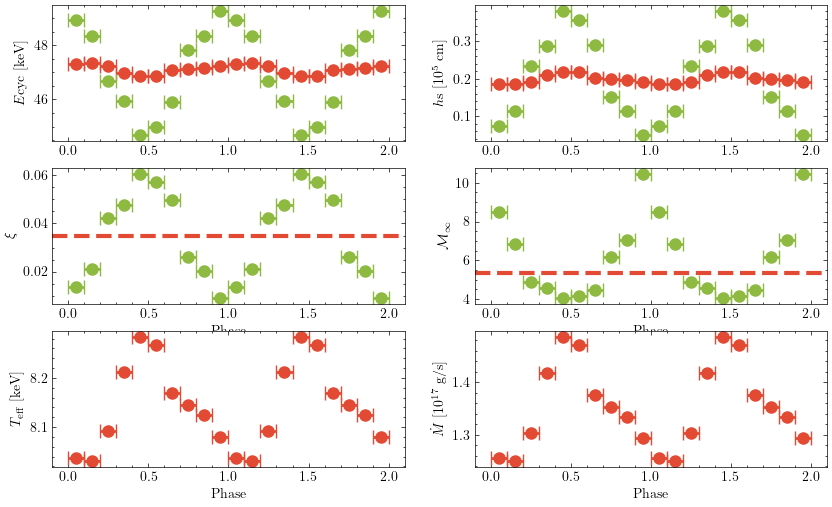

In [10]:
L_X = L_X3
E_cyc_obs = E_cyc_obs3
Lambda=0.5

# Calculate h_s using the given formula
E_0 = 50
xi = 0.001

h_s = 2.28e3 * (xi / 0.01) * (M_star / 1.4)**(-1) * (R_star_cm / 10**6) * (L_X / L_X_norm) #super-critical
E_cyc = E_0 * (R_star_cm / (R_star_cm + h_s))**3

# Calculate h_s using the given formula
h_s_obs = R_star_cm * ((E_0 / E_cyc_obs)**(1/3) - 1)



H_obs = 1.14e5 * (M_star / 1.4)**-1 * (R_star_cm / 10**6) * (L_X / L_X_norm)
xi_obs = xi * h_s_obs / h_s
xi = np.mean(xi_obs)
print(xi)
h_s = 2.28e3 * (xi / 0.01) * (M_star / 1.4)**(-1) * (R_star_cm / 10**6) * (L_X / L_X_norm) #super-critical
E_cyc = E_0 * (R_star_cm / (R_star_cm + h_s))**3

Mach_obs = (xi_obs)**(-1/2)
T_eff = 4.35e7 * (Lambda/0.1)**(1/4) * (M_star/1.4)**(-5/56) * (R_star_cm/1e6)**(-15/56) * (B_star/1e12)**(1/7) * (L_X/1e37)**(5/28)
r_0 = 1.93e5 * (Lambda/0.1)**(-1/2) * (M_star/1.4)**(-1/14) * (R_star_cm/1e6)**(11/14) * (B_star/1e12)**(-2/7) * (L_X/1e37)**(1/7)
dot_M = L_X * R_star_cm / (G * M_0)
P_rad = a * T_eff**4 / 3 

print(np.mean(E_cyc),np.mean(E_cyc_obs))


fig, axs = plt.subplots(3, 2, figsize=(10, 6))
axs[0,0].errorbar(x_data, np.hstack([E_cyc,E_cyc]), xerr=x_err, 
             fmt='o', color=colors['red'], ecolor=colors['red'], capsize=5, markersize=8, elinewidth=2)
axs[0,0].errorbar(x_data, np.hstack([E_cyc_obs,E_cyc_obs]), xerr=x_err, 
             fmt='o', color=colors['green'], ecolor=colors['green'], capsize=5, markersize=8, elinewidth=2)
axs[0,0].set_ylabel(r'$E{\rm cyc}$ [keV]')

axs[0,1].errorbar(x_data, np.hstack([h_s,h_s])/1e5, xerr=x_err, 
             fmt='o', color=colors['red'], ecolor=colors['red'], capsize=5, markersize=8, elinewidth=2)
axs[0,1].errorbar(x_data, np.hstack([h_s_obs,h_s_obs])/1e5, xerr=x_err, 
             fmt='o', color=colors['green'], ecolor=colors['green'], capsize=5, markersize=8, elinewidth=2)
axs[0,1].set_ylabel(r'$h{\rm s}$ [$10^5$ cm]')

axs[1,0].axhline(y=xi, color=colors['red'], linestyle='--',lw=3,label=r'\xi_{\rm mean}: %s'%xi)
axs[1,0].errorbar(x_data, np.hstack([xi_obs,xi_obs]), xerr=x_err, 
             fmt='o', color=colors['green'], ecolor=colors['green'], capsize=5, markersize=8, elinewidth=2)
axs[1,0].set_ylabel(r'$\xi$')

axs[1,1].axhline(y=xi**(-1/2), color=colors['red'], linestyle='--',lw=3)
axs[1,1].errorbar(x_data, np.hstack([Mach_obs,Mach_obs]), xerr=x_err, 
             fmt='o', color=colors['green'], ecolor=colors['green'], capsize=5, markersize=8, elinewidth=2)
axs[1,1].set_ylabel(r'$\mathcal{M}_{\infty}$')
axs[1,0].set_xlabel(r'Phase')
axs[1,1].set_xlabel(r'Phase')


axs[2,0].errorbar(x_data, np.hstack([T_eff,T_eff])*8.62e-8, xerr=x_err, 
             fmt='o', color=colors['red'], ecolor=colors['red'], capsize=5, markersize=8, elinewidth=2)
axs[2,0].set_ylabel(r'$T_{\rm eff}$ [keV]')

axs[2,1].errorbar(x_data, np.hstack([dot_M,dot_M])/1e17, xerr=x_err, 
             fmt='o', color=colors['red'], ecolor=colors['red'], capsize=5, markersize=8, elinewidth=2)
axs[2,1].set_ylabel(r'$\dot{M}$ [$10^{17}$ g/s]')
axs[2,0].set_xlabel(r'Phase')
axs[2,1].set_xlabel(r'Phase')
#axs[3,0].errorbar(x_data, np.hstack([P_rad,P_rad])/1e17, xerr=x_err, 
#             fmt='o', color=colors['red'], ecolor=colors['red'], capsize=5, markersize=8, elinewidth=2)
#axs[3,0].set_ylabel(r'$P_{\rm rad}$ [dyne/cm$^2$]')

#plt.savefig('column_radiation_20201120.pdf')
print(np.mean(dot_M))

0.019398112883573928


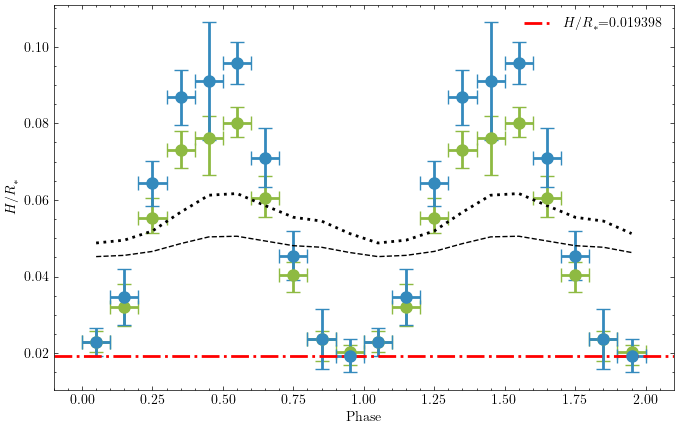

In [117]:
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt

# --------------------
E_cyc_obs = E_cyc_obs1
E_cyc_obs_err = E_cyc_obs1_err
L_X = L_X1
# --------------------
# 模型参数
Ec_star = 83.44  # keV
rsR = 0.41       # r_s / R_*
k0 = 0.4734
#Lcr = 9.529127027699219e+37
Lcr = 6.37e37
aR = 0.01636
a = aR * 1e6
def compute_H_from_Lx(Lx, Lcr, a, k):
    """
    使用公式 H = a * (Lx / Lcr)^(1/k) 反解高度
    :param Lx: array-like, X-ray luminosity (erg/s)
    :param Lcr: 临界光度
    :param a: 常数 a（与中子星有关）
    :param k: 指数 k，通常 ≈ 1
    """
    return a * (Lx / Lcr)**(1 / k)


H1 = compute_H_from_Lx(L_X, Lcr, a, k0)/1e6

def e_model(H_tilde, Ec_star, rsR):
    term1 = 1 - rsR / (1 + H_tilde)
    term2 = (1 / (1 + H_tilde))**3
    return term1 * term2 * Ec_star

# 单点反解函数
def solve_H_tilde(E_obs, Ec_star=Ec_star, rsR=rsR):
    try:
        return brentq(lambda H: e_model(H, Ec_star, rsR) - E_obs, 1e-4, 100)
    except ValueError:
        return np.nan

# --------------------
# 反解中心值和误差上下限
H_c = []
H_l = []
H_r = []

for E, err_l, err_r in zip(E_cyc_obs, E_cyc_obs_err[0], E_cyc_obs_err[1]):
    H0 = solve_H_tilde(E)
    Hlo = solve_H_tilde(E - err_l)
    Hhi = solve_H_tilde(E + err_r)
    H_c.append(H0)
    H_l.append(H0 - Hlo)
    H_r.append(Hhi - H0)

H_c = np.array(H_c)
H_l = np.array(H_l)
H_r = np.array(H_r)

# --------------------
# 绘图：带误差的 H/R*
plt.figure(figsize=(8, 5))
plt.errorbar(x_data, np.hstack([h_s,h_s])/1e6,
             fmt='--', color='black', ecolor='black')
plt.errorbar(x_data, np.hstack([H1,H1]), 
             fmt=':', color='black', ecolor='black',lw=2)
plt.errorbar(x_data, np.hstack([h_s_obs,h_s_obs])/1e6, xerr=x_err, yerr=np.hstack([np.abs(h_s_obs_err)/1e6,np.abs(h_s_obs_err)/1e6]),
             fmt='o', color=colors['green'], ecolor=colors['green'], capsize=5, markersize=8, elinewidth=2)
plt.errorbar(x_data, np.hstack([H_c,H_c]), xerr=x_err, yerr=np.hstack([np.abs(H_l),np.abs(H_l)]),
             fmt='o', color=colors['blue'], ecolor=colors['blue'], capsize=5, markersize=8, elinewidth=2)
plt.axhline(y=np.nanmin(H_c), color='red', linestyle='-.', linewidth=2,label=r'$H/R_*$=%f'%np.nanmin(H_c))
print(np.nanmin(H_c))
#plt.xlabel(r'$E_{\mathrm{CRSF}}$ (keV)')
plt.xlabel('Phase')
plt.ylabel(r'$H/R_*$')
#plt.grid(True)
#plt.title("反解高度与观测CRSF能量的关系（含误差）")
#plt.tight_layout()
plt.legend()
plt.show()

In [86]:
H_test = np.linspace(0.01, 100, 1000)
E_model_test = e_model(H_test, Ec_star=83.44, rsR=0.41)

print(f"模型最小值: {E_model_test.min():.4f} keV")
print(f"模型最大值: {E_model_test.max():.4f} keV")
print(f"观测值范围: {E_cyc_obs2.min():.4f} ~ {E_cyc_obs2.max():.4f} keV")


模型最小值: 0.0001 keV
模型最大值: 48.1105 keV
观测值范围: 45.8961 ~ 49.4778 keV


In [5]:
np.mean(dot_M)

6.078826342996928e+17